# PregnaCare — Maternal Risk Prediction Model

This notebook is in two parts. Part 1 uses the Rwanda DHS 2019-20 to establish the
local need and to show that survey data alone cannot predict acute risk. Part 2 trains
the clinical-vitals classifier that powers the application.

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import zipfile

zip_path = '/content/drive/MyDrive/pregnacare/RW_2019-20_DHS_06082026_76_250739.zip'

with zipfile.ZipFile(zip_path) as z:
    z.extract('RWIR81DT/RWIR81FL.DTA', '/content')

print('Extracted to /content/RWIR81DT/RWIR81FL.DTA')

Extracted to /content/RWIR81DT/RWIR81FL.DTA


In [24]:
import pandas as pd

# The file has 5117 variables, so we load only the ones we'll use.
# Each is chosen because it's clinically relevant and a woman could report it herself.
cols = [
    'caseid',
    'v012',   # age
    'v013',   # age group
    'v024',   # region
    'v025',   # urban / rural
    'v106',   # education level
    'v190',   # wealth index
    'v201',   # total children ever born (parity)
    'v208',   # births in last 5 years
    'v213',   # currently pregnant
    'v228',   # ever had a terminated pregnancy
    'v437',   # weight (kg, stored x10)
    'v438',   # height (cm, stored x10)
    'v445',   # body mass index (stored x100)
    'v463a',  # smokes cigarettes
    'm14_1',  # number of antenatal visits (most recent birth)
    'm15_1',  # place of delivery
    'm17_1',  # delivery by caesarean
    'm18_1',  # size of baby at birth
    'b5_01',  # most recent child is alive
    'b11_01', # preceding birth interval (months)
]

df = pd.read_stata('/content/RWIR81DT/RWIR81FL.DTA', columns=cols, convert_categoricals=False)

print('Total women interviewed:', len(df))
print('Women with a birth in the last 5 years:', (df['v208'] > 0).sum())
print('Women currently pregnant:', (df['v213'] == 1).sum())
df.head()

Total women interviewed: 14634
Women with a birth in the last 5 years: 6167
Women currently pregnant: 843


,caseid,v012,v013,v024,v025,v106,v190,v201,v208,v213,...,v437,v438,v445,v463a,m14_1,m15_1,m17_1,m18_1,b5_01,b11_01
0,1 3 02,24,2,1,2,3,4,0,0,0,...,574.0,1694.0,2000.0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,1 4 01,42,6,1,2,1,3,2,0,0,...,588.0,1570.0,2385.0,0,NaN,NaN,NaN,NaN,1.0,30.0
2,1 5 02,32,4,1,2,2,5,2,0,0,...,642.0,1621.0,2443.0,0,NaN,NaN,NaN,NaN,1.0,38.0
3,1 6 03,29,3,1,2,2,3,0,0,0,...,608.0,1604.0,2363.0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,1 7 02,36,5,1,2,2,4,3,1,0,...,508.0,1601.0,1982.0,0,4.0,22.0,1.0,5.0,1.0,39.0


## Section 1 — The Rwandan context (DHS 2019-20)

The Rwanda DHS shows where the maternal-health gaps are. Antenatal care adequacy tracks
closely with wealth, so the women least likely to receive adequate care are also the poorest.

### Analysis sample and risk label

We keep women with a birth in the last five years and build a composite risk label from
five recorded adverse indicators. These variables are used for analysis only, never as
model features.

In [25]:
import numpy as np

data = df[df['v208'] > 0].copy()

anc = data['m14_1'].replace(98, np.nan)

data['ind_death']     = (data['b5_01'] == 0).astype(int)
data['ind_loss']      = (data['v228'] == 1).astype(int)
data['ind_small']     = data['m18_1'].isin([4, 5]).astype(int)
data['ind_low_anc']   = (anc < 4).astype(int)
data['ind_short_gap'] = (data['b11_01'] < 24).astype(int)

flags = ['ind_death', 'ind_loss', 'ind_small', 'ind_low_anc', 'ind_short_gap']
data['risk_score'] = data[flags].sum(axis=1)
data['risk'] = pd.cut(data['risk_score'], bins=[-1, 0, 1, 99],
                      labels=['low', 'moderate', 'high'])

data['risk'].value_counts().reindex(['low', 'moderate', 'high'])

,count
risk,
low,1822
moderate,2865
high,1480


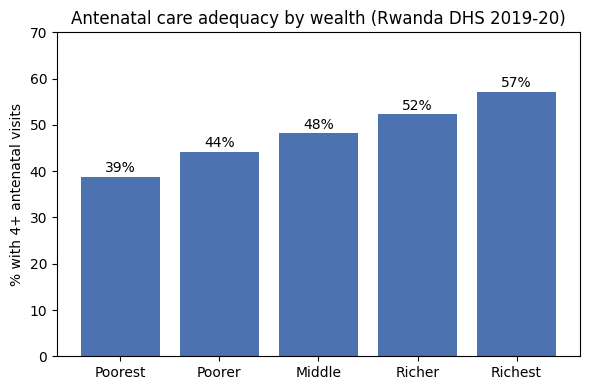

Overall, only 47.6% of women received the recommended 4+ ANC visits


In [26]:
import matplotlib.pyplot as plt

anc = data['m14_1'].replace(98, np.nan)
data['anc_adequate'] = (anc >= 4).astype(float)

wealth_anc = data.groupby('v190')['anc_adequate'].mean() * 100

plt.figure(figsize=(6, 4))
plt.bar(['Poorest', 'Poorer', 'Middle', 'Richer', 'Richest'],
        wealth_anc.values, color='#4c72b0')
plt.ylabel('% with 4+ antenatal visits')
plt.title('Antenatal care adequacy by wealth (Rwanda DHS 2019-20)')
plt.ylim(0, 70)
for i, v in enumerate(wealth_anc.values):
    plt.text(i, v + 1, f'{v:.0f}%', ha='center')
plt.tight_layout()
plt.show()

print('Overall, only %.1f%% of women received the recommended 4+ ANC visits'
      % (data['anc_adequate'].mean() * 100))

The same women carry a real burden of risk factors, but these are recorded *outcomes*,
not signs that warn a woman in time.

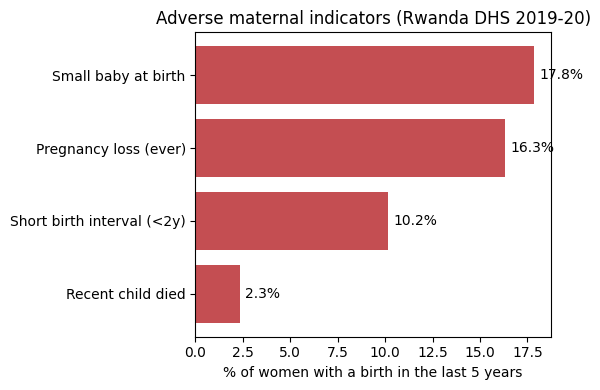

In [27]:
outcomes = {
    'Pregnancy loss (ever)': (data['v228'] == 1).mean() * 100,
    'Small baby at birth': data['m18_1'].isin([4, 5]).mean() * 100,
    'Short birth interval (<2y)': (data['b11_01'] < 24).mean() * 100,
    'Recent child died': (data['b5_01'] == 0).mean() * 100,
}
s = pd.Series(outcomes).sort_values()

plt.figure(figsize=(6, 4))
plt.barh(s.index, s.values, color='#c44e52')
plt.xlabel('% of women with a birth in the last 5 years')
plt.title('Adverse maternal indicators (Rwanda DHS 2019-20)')
for i, v in enumerate(s.values):
    plt.text(v + 0.3, i, f'{v:.1f}%', va='center')
plt.tight_layout()
plt.show()

## Can this survey data predict acute risk? No — and that is the point

We train a model to predict a composite risk label from the DHS demographic and
history variables. It barely beats a majority-class baseline, because acute obstetric
risk is driven by clinical signs (blood pressure, blood sugar, temperature) that a
household survey does not collect. This is why the prediction model is built on
clinical vitals instead.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

feat = data[['v012', 'v201', 'v106', 'v190', 'v025', 'v213', 'v463a', 'v024']].copy()
feat.columns = ['age', 'parity', 'education', 'wealth',
                'residence', 'pregnant_now', 'smokes', 'region']
feat['residence'] = (feat['residence'] == 1).astype(int)

Xd = pd.get_dummies(feat, columns=['region'], prefix='region', dtype=int)
yd = data['risk'].map({'low': 0, 'moderate': 1, 'high': 2})

Xtr, Xte, ytr, yte = train_test_split(Xd, yd, test_size=0.25,
                                      stratify=yd, random_state=42)

rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                            random_state=42).fit(Xtr, ytr)
base = DummyClassifier(strategy='most_frequent').fit(Xtr, ytr)

print('Majority baseline F1:', round(f1_score(yte, base.predict(Xte), average='weighted'), 3))
print('Demographic model F1:', round(f1_score(yte, rf.predict(Xte), average='weighted'), 3))

Majority baseline F1: 0.294
Demographic model F1: 0.394


## Section 2 — The clinical vitals dataset (model training data)

The DHS sections above stay as Rwandan context. From here the classifier is trained on
clinical vitals, which is what the application collects.

In [29]:
!pip install ucimlrepo -q
from ucimlrepo import fetch_ucirepo

maternal = fetch_ucirepo(id=863)
mh = pd.concat([maternal.data.features, maternal.data.targets], axis=1)

print('shape:', mh.shape)
print(mh['RiskLevel'].value_counts())
mh.head()

shape: (1014, 7)
RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


### Exploring the vitals dataset

Before training, we look at the class balance, the spread of each vital, and how the
vitals relate to one another.

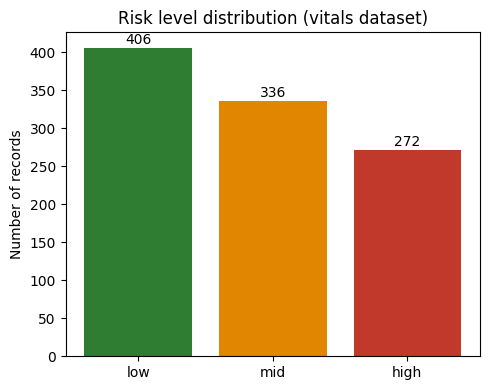

In [39]:
import matplotlib.pyplot as plt

counts = mh['RiskLevel'].value_counts().reindex(['low risk', 'mid risk', 'high risk'])

plt.figure(figsize=(5, 4))
plt.bar(['low', 'mid', 'high'], counts.values,
        color=['#2e7d32', '#e08600', '#c0392b'])
plt.ylabel('Number of records')
plt.title('Risk level distribution (vitals dataset)')
for i, v in enumerate(counts.values):
    plt.text(i, v + 5, str(v), ha='center')
plt.tight_layout()
plt.show()

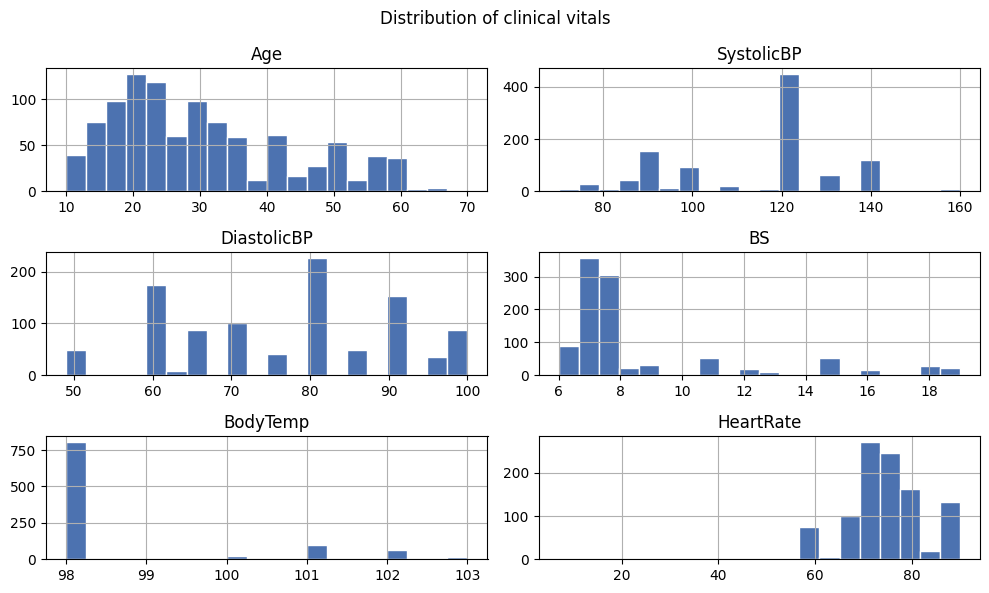

In [40]:
vitals = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

mh[vitals].hist(figsize=(10, 6), bins=20, color='#4c72b0', edgecolor='white')
plt.suptitle('Distribution of clinical vitals')
plt.tight_layout()
plt.show()

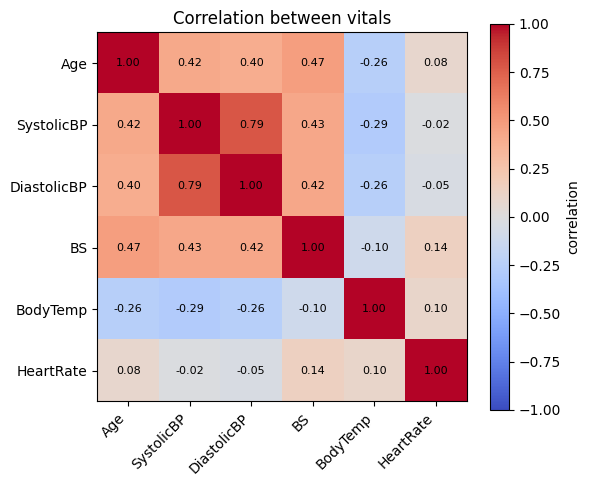

In [41]:
corr = mh[vitals].corr()

plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='correlation')
plt.xticks(range(len(vitals)), vitals, rotation=45, ha='right')
plt.yticks(range(len(vitals)), vitals)
for i in range(len(vitals)):
    for j in range(len(vitals)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
plt.title('Correlation between vitals')
plt.tight_layout()
plt.show()

### Feature engineering and split (with SMOTE on training only)

In [30]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

mh['MAP'] = (mh['SystolicBP'] + 2 * mh['DiastolicBP']) / 3   # mean arterial pressure
mh['PulsePressure'] = mh['SystolicBP'] - mh['DiastolicBP']

X = mh.drop(columns='RiskLevel')
y = mh['RiskLevel'].map({'low risk': 0, 'mid risk': 1, 'high risk': 2})

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

X_train, y_train = SMOTE(random_state=42).fit_resample(X_train, y_train)

print('train', X_train.shape, 'val', X_val.shape, 'test', X_test.shape)

train (852, 8) val (152, 8) test (153, 8)


## Section 3 — Train and compare three models

In [31]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score

models = {
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss'),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    f1 = f1_score(y_val, pred, average='weighted')
    acc = accuracy_score(y_val, pred)
    print(f'{name:20s} weighted-F1 {f1:.3f}   accuracy {acc:.3f}')

XGBoost              weighted-F1 0.875   accuracy 0.875
Random Forest        weighted-F1 0.830   accuracy 0.829
Logistic Regression  weighted-F1 0.636   accuracy 0.638


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Section 4 — Tune XGBoost (5-fold CV, SMOTE inside each fold)

In [32]:
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

X_tr_raw, _, y_tr_raw, _ = train_test_split(X, y, test_size=0.30,
                                            stratify=y, random_state=42)

pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=1)),
])

grid = {
    'xgb__n_estimators': [200, 400],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.05, 0.1],
    'xgb__subsample': [0.8, 1.0],
}

search = GridSearchCV(pipe, grid, cv=5, scoring='f1_weighted', n_jobs=-1)
search.fit(X_tr_raw, y_tr_raw)

print('best params:', search.best_params_)
print('best CV weighted-F1:', round(search.best_score_, 3))

best = search.best_estimator_


best params: {'xgb__learning_rate': 0.05, 'xgb__max_depth': 7, 'xgb__n_estimators': 200, 'xgb__subsample': 1.0}
best CV weighted-F1: 0.807


## Model architecture

The classifier is XGBoost (Extreme Gradient Boosting), an ensemble of decision trees
built one after another, where each new tree corrects the errors of the ones before it.

XGBoost is tree-based, not a neural network, so it has no layers or activation
functions. The equivalent structural choices are the number of trees (boosting rounds),
the maximum depth of each tree, the learning rate (how much each tree contributes), and
the subsample ratio (the fraction of rows each tree sees).

Input: eight features — the six clinical vitals plus the engineered mean arterial
pressure and pulse pressure. Output: a softmax over three risk levels (low, mid, high),
giving a probability for each.

Training minimises multiclass log-loss. Class imbalance is handled with SMOTE applied
inside each cross-validation fold, and the hyperparameters were selected by 5-fold
cross-validated grid search optimising weighted F1.

In [43]:
final_model = best.named_steps['xgb']
p = final_model.get_params()

print('Algorithm     :', type(final_model).__name__)
print('Input features:', final_model.n_features_in_)
print('Output classes:', final_model.n_classes_)
print('Objective     :', p.get('objective'))
print('Trees         :', p.get('n_estimators'))
print('Max depth     :', p.get('max_depth'))
print('Learning rate :', p.get('learning_rate'))
print('Subsample     :', p.get('subsample'))

Algorithm     : XGBClassifier
Input features: 8
Output classes: 3
Objective     : multi:softprob
Trees         : 200
Max depth     : 7
Learning rate : 0.05
Subsample     : 1.0


## Section 5 — Evaluation on the held-out test set

In [33]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, roc_auc_score)

best = search.best_estimator_
y_pred = best.predict(X_test)
y_proba = best.predict_proba(X_test)

print('Test weighted-F1:', round(f1_score(y_test, y_pred, average='weighted'), 3))
print('Test AUC-ROC    :', round(roc_auc_score(y_test, y_proba,
                                  multi_class='ovr', average='macro'), 3))
print()
print(classification_report(y_test, y_pred, target_names=['low', 'mid', 'high']))
print('Confusion matrix (rows = actual, cols = predicted):')
print(confusion_matrix(y_test, y_pred))

Test weighted-F1: 0.784
Test AUC-ROC    : 0.896

              precision    recall  f1-score   support

         low       0.78      0.80      0.79        61
         mid       0.69      0.67      0.68        51
        high       0.90      0.90      0.90        41

    accuracy                           0.78       153
   macro avg       0.79      0.79      0.79       153
weighted avg       0.78      0.78      0.78       153

Confusion matrix (rows = actual, cols = predicted):
[[49 12  0]
 [13 34  4]
 [ 1  3 37]]


### Confusion matrix

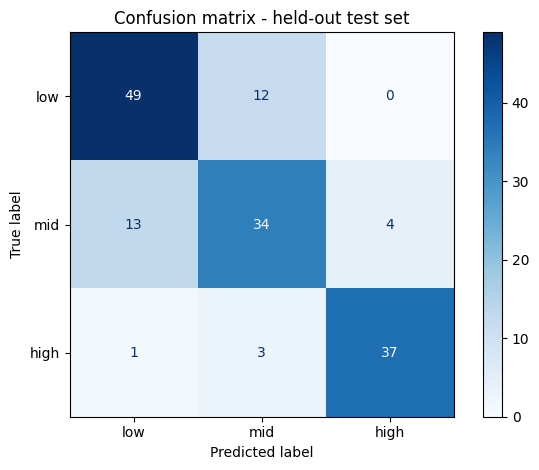

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, best.predict(X_test),
    display_labels=['low', 'mid', 'high'], cmap='Blues')
plt.title('Confusion matrix - held-out test set')
plt.tight_layout()
plt.show()

### ROC curves (one-vs-rest)

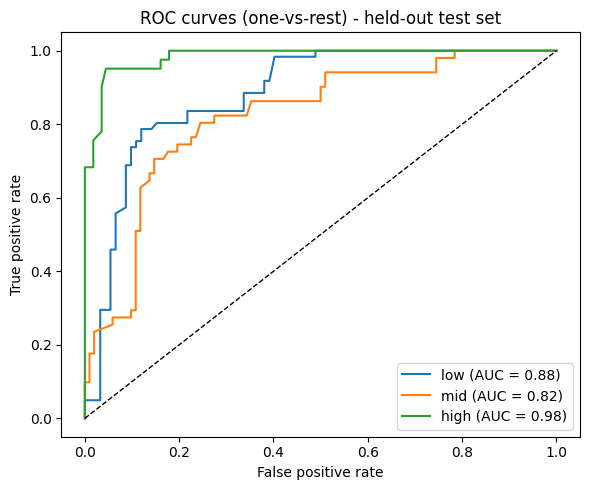

In [35]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes = ['low', 'mid', 'high']
y_bin = label_binarize(y_test, classes=[0, 1, 2])
y_proba = best.predict_proba(X_test)

plt.figure(figsize=(6, 5))
for i, name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curves (one-vs-rest) - held-out test set')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Edge-case testing

We feed the model archetypal clinical profiles to check it responds sensibly to inputs
it should clearly recognise, rather than only optimising an aggregate score.

In [36]:
def make_patient(age, sbp, dbp, bs, temp, hr):
    return pd.DataFrame([{
        'Age': age, 'SystolicBP': sbp, 'DiastolicBP': dbp, 'BS': bs,
        'BodyTemp': temp, 'HeartRate': hr,
        'MAP': (sbp + 2 * dbp) / 3, 'PulsePressure': sbp - dbp,
    }])[X.columns]

cases = {
    'Healthy young woman':          make_patient(22, 110, 70, 6.5, 98, 72),
    'Severe pre-eclampsia signs':   make_patient(38, 160, 110, 8.0, 98, 88),
    'Very high blood sugar':        make_patient(35, 120, 80, 15.0, 98, 80),
    'Fever / possible infection':   make_patient(28, 115, 75, 7.0, 103, 95),
}

classes = ['low', 'mid', 'high']
for name, p in cases.items():
    print(f'{name:30s} -> {classes[best.predict(p)[0]]} risk')

Healthy young woman            -> low risk
Severe pre-eclampsia signs     -> high risk
Very high blood sugar          -> high risk
Fever / possible infection     -> mid risk


## Section 6 — SHAP explanations

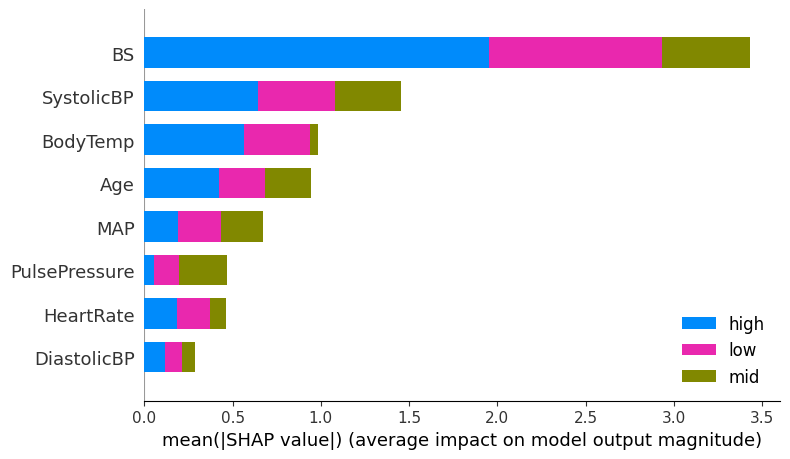

In [37]:
!pip install shap -q
import shap

model = best.named_steps['xgb']          # the trained XGBoost inside the tuned pipeline
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type='bar',
                  class_names=['low', 'mid', 'high'])

### Explain a single prediction (what the app shows each woman)

In [38]:
classes = ['low', 'mid', 'high']

i = 0                                  # pick one woman from the test set
patient = X_test.iloc[[i]]
pred = model.predict(patient)[0]

print('Predicted risk level:', classes[pred])
print('Actual risk level   :', classes[y_test.iloc[i]])
print()

sv = explainer.shap_values(patient)
vals = sv[pred][0] if isinstance(sv, list) else sv[0, :, pred]

contrib = pd.Series(vals, index=X_test.columns).sort_values(key=abs, ascending=False)
print('Top factors driving this prediction:')
print(contrib.head(4).round(3))

Predicted risk level: high
Actual risk level   : high

Top factors driving this prediction:
BS             2.745
Age            1.385
SystolicBP    -0.237
DiastolicBP    0.162
dtype: float32


## Section 7 — Save the model for the backend

In [42]:
import joblib

bundle = {
    'model': model,                       # trained XGBoost
    'features': list(X.columns),          # exact feature order the model expects
    'classes': ['low', 'mid', 'high'],    # maps prediction 0/1/2 to a label
}

joblib.dump(bundle, '/content/drive/MyDrive/pregnacare/pregnacare_model.pkl')
print('Saved. Features in order:', bundle['features'])

Saved. Features in order: ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'MAP', 'PulsePressure']


## Summary of results

Model: XGBoost classifier on maternal clinical vitals (six collected values plus two
engineered features, mean arterial pressure and pulse pressure).

Held-out test performance:
- Weighted F1: 0.78
- AUC-ROC: 0.90
- High-risk class: precision 0.90, recall 0.90 (only 1 high-risk case misread as low)

Robustness and trust:
- Cross-validated during tuning with SMOTE applied inside each fold.
- SHAP shows the top drivers are blood sugar, systolic BP, body temperature, and age,
  which match established obstetric risk factors.
- Edge-case tests return clinically sensible predictions on archetypal profiles.

Note: the source dataset contained 55% duplicate rows. Full-data performance
is 0.78; after removing duplicates it is 0.66. As the data has no patient identifiers,
duplicates cannot be confirmed as repeated records versus distinct patients with
identical vitals.

Limitation: the model is trained on non-Rwandan clinical data because no public Rwandan
vitals dataset exists; the DHS analysis establishes the Rwandan need, and the vitals
transfer because they are physiological. Collecting Rwandan vitals data for local
fine-tuning is identified as future work.